## 1. Постановка задачи


В данном проекте вы решите настоящую бизнес-задачу в области маркетинга. Вам предстоит произвести сегментацию клиентов на основе их покупательской способности, частоты совершения заказов и срока давности последнего заказа, а также определить оптимальную стратегию взаимодействия с ними.
<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. 

**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку набора данных.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать категории товаров и клиентов. 
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать вашу модель на новых клиентах.



## 2. Знакомство с данными. 

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn import mixture
from sklearn import manifold
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import cluster
from sklearn import metrics
from sklearn import model_selection
from sklearn import decomposition
from sklearn import ensemble
import warnings 

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

Первым делом необходимо понять, с какими данными нам предстоит работать, и произвести базовую предобработку данных, переведя признаки в необходимые для дальнейшей работы форматы.


Для начала давайте познакомимся с нашими данными:

In [74]:
data = pd.read_csv(
    r"C:\Users\aleks\Downloads\customer_segmentation_project.csv", 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


Итак, у нас есть данные о более чем полумиллионе транзакций. Каждая из них описывается следующими признаками:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* Stock Code — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию; 
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.

Проведём анализ структуры таблицы.


### Задание 2.1
Сколько столбцов в данных кодируются числовыми типами (int/float)?

In [75]:
# Посмотреть типы данных всех столбцов
print(data.dtypes)

# Посчитать количество числовых столбцов
numeric_cols = data.select_dtypes(include=['int64', 'float64'])
print(f"Количество числовых столбцов: {len(numeric_cols.columns)}")
print(f"Названия: {numeric_cols.columns.tolist()}")

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object
Количество числовых столбцов: 2
Названия: ['Quantity', 'UnitPrice']


### Задание 2.2
Выберите столбцы, в которых есть хотя бы один пропуск:
* InvoiceNo
* StockCode
* Description
* CustomerID
* Country 

In [77]:
missing = data.isna().sum()
print(missing[missing > 0])

Description      1454
CustomerID     135080
dtype: int64


### Задание 2.3
Судя по описанию задачи, нам должны были предоставить данные за годовой период — проверим, так ли это.

Преобразуйте столбец InvoiceDate в формат datetime.
Укажите, за какой промежуток времени представлены данные:

* 2010-12-01 to 2011-12-09
* 2011-12-01 to 2012-12-09
* 2010-01-01 to 2011-01-09
* 2020-12-01 to 2021-12-09


In [78]:
# Преобразование InvoiceDate в datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Проверка диапазона дат
print(f"Минимальная дата: {data['InvoiceDate'].min()}")
print(f"Максимальная дата: {data['InvoiceDate'].max()}")

# Или в формате YYYY-MM-DD
print(f"\nДиапазон: {data['InvoiceDate'].min().strftime('%Y-%m-%d')} to {data['InvoiceDate'].max().strftime('%Y-%m-%d')}")

Минимальная дата: 2010-12-01 08:26:00
Максимальная дата: 2011-12-09 12:50:00

Диапазон: 2010-12-01 to 2011-12-09


### Задание 2.4

1) Каково максимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

2) Каково минимальное количество товаров в заказе (Quantity)? Ответ приведите в виде целого числа.

3) Сколько, согласно данным, стоит самый дешёвый товар (за исключением товаров с отрицательной стоимостью)?

In [80]:
# 1) Максимальное количество товаров в заказе
max_quantity = data['Quantity'].max()
print(f"1) Максимальное количество товаров: {int(max_quantity)}")

# 2) Минимальное количество товаров в заказе
min_quantity = data['Quantity'].min()
print(f"2) Минимальное количество товаров: {int(min_quantity)}")

# 3) Самый дешёвый товар (без отрицательных цен)
min_price = data[data['UnitPrice'] > 0]['UnitPrice'].min()
print(f"3) Минимальная цена товара: {min_price:.2f}")

1) Максимальное количество товаров: 80995
2) Минимальное количество товаров: -80995
3) Минимальная цена товара: 0.00


### Задание 2.5
1) Сколько уникальных клиентов покупали товары за период выгрузки датасета?

2) Сколько уникальных стран содержится в столбце Country (исключая специальный код 'Unspecified', обозначающий неопределенную страну)?

3) Укажите идентификатор самого популярного товара (StockCode):
* 85123A
* 64812
* 51242
* 24151B


In [90]:
# 1) Количество уникальных клиентов
unique_customers = data['CustomerID'].nunique()
print(f"1) Уникальных клиентов: {unique_customers}")

# 2) Количество уникальных стран (исключая 'Unspecified')
unique_countries = data[data['Country'] != 'Unspecified']['Country'].nunique()
print(f"2) Уникальных стран (без Unspecified): {unique_countries}")

# 3) Самый популярный товар (StockCode)
most_popular_by_transactions = data['StockCode'].value_counts().idxmax()
print(f"3) Самый популярный товар (по транзакциям): {most_popular_by_transactions}")


1) Уникальных клиентов: 4372
2) Уникальных стран (без Unspecified): 37
3) Самый популярный товар (по транзакциям): 85123A


## 3. Предобработка и очистка данных

На этом этапе нам предстоит подготовить наш датасет для дальнейшего моделирования, произведя очистку данных.


### Задание 3.1
Начнем с пропусков. 

1) Сколько всего в таблице пропущенных значений?

2) Пропуски в столбце с идентификатором клиента и описанием товара свидетельствуют о некорректных/незавершённых транзакциях.

Удалите строки, содержащие пропуски в этих столбцах. Сколько строк осталось в таблице?



In [91]:
# 1) Сколько всего в таблице пропущенных значений?
total_missing = data.isna().sum().sum()
print(total_missing)

# 2) Удаление строк с пропусками в CustomerID и Description
data = data.dropna(subset=['CustomerID', 'Description'])
print(len(data))

136534
406829


### Задание 3.2
Следом за пропусками проверим наличие дубликатов.

1) Сколько в таблице полностью дублирующихся записей?

2) Удалите дубликаты из таблицы. Сколько строк осталось?



In [92]:
# 1) Количество полностью дублирующихся записей
dup_count = data.duplicated().sum()
print(dup_count)

# 2) Удаление дубликатов и количество строк после этого
data = data.drop_duplicates()
print(len(data))

5225
401604


Ранее мы заметили, что в столбце с количеством товара есть отрицательные значения. Давайте разберемся, откуда они взялись. Выведем первые 5 строк таблицы, в которой столбец Quantity меньше 0.

In [93]:
negative_quantity = data[(data['Quantity']<0)]
print('Count of entries with a negative number: {}'.format(negative_quantity.shape[0]))
negative_quantity.head()

Count of entries with a negative number: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


### Задание 3.3
Давайте проверим, что все записи из таблицы с отрицательным количеством товара действительно являются возвратными транзакциями. Если транзакция не является возвратом, но содержит отрицательное количество товара, это будет поводом считать её выбросом.

Сколько транзакций из таблицы negative_quantity не содержат в номере заказа признак возврата?

In [94]:
# Фильтрация записей с отрицательным Quantity
negative_quantity = data[data['Quantity'] < 0]

# Проверка: транзакции с отрицательным Quantity должны иметь 'C' в начале InvoiceNo
# Возвратные транзакции = те, у которых InvoiceNo начинается с 'C'
non_return_transactions = negative_quantity[~negative_quantity['InvoiceNo'].str.startswith('C', na=False)]

print(len(non_return_transactions))

0


Давайте подробнее разберёмся с возвратами. Сейчас на каждый уникальный товар заведена отдельная строка в таблице — это мешает определить общее количество возвратов.

Чтобы подсчитать число возвратов, сначала необходимо определить, сколько уникальных товаров указано в транзакции (корзине/basket) для каждой уникальной пары «клиент-заказ»:


In [95]:
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


### Задание 3.4
Добавьте во вспомогательную таблицу nb_products_per_basket признак отмены заказа (order_canceled): он равен 1, если транзакция является возвратом, и 0 — в противном случае.

Сколько процентов заказов в таблице являются возвратами? Ответ приведите в виде целого числа.


In [97]:
# Создание вспомогательной таблицы
temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns={'InvoiceDate': 'Number of products'})

# Добавление признака order_canceled (1 если InvoiceNo начинается с 'C', иначе 0)
nb_products_per_basket['order_canceled'] = (nb_products_per_basket['InvoiceNo'].str.startswith('C', na=False)).astype(int)

# Процент возвратов
cancel_percentage = (nb_products_per_basket['order_canceled'].sum() / len(nb_products_per_basket)) * 100
print(round(cancel_percentage))

16


Давайте поближе взглянем на отмененные заказы:


In [98]:
nb_products_per_basket[nb_products_per_basket['order_canceled']==1].head()

,CustomerID,InvoiceNo,Number of products,order_canceled
1,12346,C541433,1,1
23,12352,C545329,2,1
24,12352,C545330,1,1
25,12352,C547388,7,1
39,12359,C549955,2,1


Найдем в таблице со всеми транзакциями записи принадлежащие клиенту с идентификатором 12346:


In [99]:
data[data['CustomerID'] == '12346']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_canceled
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,0
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom,1


Итак, вот пример пары «заказ-отмена». Обратите внимание на столбцы StockCode, UnitPrice, CustomerID и Quantity, сравните их для двух транзакций. 

### Задание 3.5
Выдвигаем гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара.

* Верна ли гипотеза?
* Да, верна



In [102]:
# Создание таблицы с отрицательным Quantity
negative_quantity = data[data['Quantity'] < 0]

# Проверка гипотезы
hypothesis_true = True
for idx, row in negative_quantity.iterrows():
    # Ищем аналог с противоположным Quantity
    match = data[
        (data['CustomerID'] == row['CustomerID']) & 
        (data['StockCode'] == row['StockCode']) & 
        (data['Quantity'] == -1 * row['Quantity'])
    ]
    
    # Если не нашли ни одной записи - гипотеза неверна
    if len(match) == 0:
        hypothesis_true = False
        break

print(f"Гипотеза верна: {hypothesis_true}")

Гипотеза верна: False


Давайте приведем контр-пример, на котором "споткнулась" наша прошлая гипотеза. Посмотрим на клиента с идентификатором 14527:

In [103]:
data[data['CustomerID'] == '14527'].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_canceled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,1
8963,537159,22112,CHOCOLATE HOT WATER BOTTLE,6,2010-12-05 13:17:00,4.95,14527,United Kingdom,0
8964,537159,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-05 13:17:00,4.95,14527,United Kingdom,0
8965,537159,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-05 13:17:00,3.75,14527,United Kingdom,0
8966,537159,22114,HOT WATER BOTTLE TEA AND SYMPATHY,6,2010-12-05 13:17:00,3.95,14527,United Kingdom,0


Обратите внимание на первую строку, в которой располагается заказ C536379 с признаком отмены — противоположных ему аналогов по количеству товаров вы не найдёте. Причина кроется в типе товара: данный товар обозначен как товар со скидкой (StockCode), и, по-видимому, для таких транзакций нет аналогов с положительным числом товаров в заказе. Учтём это наблюдение на будущее.

### Задание 3.6
Выдвигаем новую гипотезу: для каждой отменённой транзакции в базе данных (таблица data) существует её аналог с тем же кодом товара, идентификатором клиента и противоположным значением количества товара, если на товар не распространяются скидки.

Верна ли гипотеза?
* Да, верна
* Нет, не верна 


In [ ]:
# Создание таблицы с отрицательным Quantity (исключая товары со скидкой "D")
negative_quantity = data[(data['Quantity'] < 0) & (data['StockCode'] != 'D')]

# Проверка гипотезы
hypothesis_true = True
for idx, row in negative_quantity.iterrows():
    # Ищем аналог с противоположным Quantity
    match = data[
        (data['CustomerID'] == row['CustomerID']) & 
        (data['StockCode'] == row['StockCode']) & 
        (data['Quantity'] == -1 * row['Quantity'])
    ]
    
    # Если не нашли ни одной записи - гипотеза неверна
    if len(match) == 0:
        hypothesis_true = False
        print(f"Контр-пример найден: {row['InvoiceNo']}, {row['StockCode']}, {row['Quantity']}")
        break

print(f"Гипотеза верна: {hypothesis_true}")

Всего отменённых транзакций: 8872
Отменённых транзакций без Discount: 8795

--- Результаты проверки гипотезы (без Discount) ---
Отменённых транзакций (без Discount): 8795
Найден оригинал для: 3117
Процент: 35.44%

 Гипотеза НЕ ВЕРНА: 5678 отмен без оригинала

--- Примеры отмен без оригинала ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,key,has_original
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,35004C_15311_1_4.65,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,22556_17548_12_1.65,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,21984_17548_24_0.29,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,21983_17548_24_0.29,False
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,21980_17548_24_0.29,False
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548,United Kingdom,21484_17548_12_3.45,False
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,22557_17548_12_1.65,False
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548,United Kingdom,22553_17548_24_1.65,False
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897,United Kingdom,22960_17897_6_4.25,False
1441,C536543,22632,HAND WARMER RED RETROSPOT,-1,2010-12-01 14:30:00,2.10,17841,United Kingdom,22632_17841_1_2.1,False


Посмотрим, где кроется наша проблема. В качестве контр-примера приведем транзакции, относящиеся к клиенту с идентификатором 15311 и товаром под кодом 35004C:


In [104]:
data[(data['CustomerID'] == '15311') & (data['StockCode'] == '35004C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_canceled
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,1
9200,537195,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-05 13:55:00,4.65,15311,United Kingdom,0
18196,C537805,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-08 13:18:00,4.65,15311,United Kingdom,1
28630,538651,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-13 15:07:00,4.65,15311,United Kingdom,0
39381,C539640,35004C,SET OF 3 COLOURED FLYING DUCKS,-3,2010-12-20 15:27:00,4.65,15311,United Kingdom,1
44157,540157,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-05 11:41:00,4.65,15311,United Kingdom,0
59542,541293,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-17 13:39:00,4.65,15311,United Kingdom,0
78333,C542866,35004C,SET OF 3 COLOURED FLYING DUCKS,-2,2011-02-01 12:14:00,4.65,15311,United Kingdom,1


* На первой строке мы видим заказ с отменой (номер заказа начинается с символа C). Однако возникает вопрос: на какой заказ пришла эта отмена, ведь более ранних записей о транзакциях, связанных с этим клиентом, нет.
Ответ состоит в том, что заказ на покупку данного товара от клиента поступил раньше декабря 2010 года, а этих данных в нашей таблице нет. Это очень популярная проблема, которая возникает практически при любой работе с транзакциями: есть только фрагмент из общих данных, однако неизвестно, что предшествовало этому фрагменту.

* По двум следующим строкам видно, что клиент может отменить не весь заказ, а только его часть (5 декабря клиент покупает 12 единиц товара, а 8 декабря оформляет возврат только на одну единицу товара). Мы должны принять это во внимание на будущее

Итак, теперь мы знаем все особенности отмены заказов. При сегментировании клиентов мы будем определять их покупательскую способность, а для этого очень важно учитывать возвраты товаров. Поэтому давайте создадим в данных о транзакциях признак QuantityCanceled, который будет указывать на количество возвращённого впоследствии товара для каждой транзакции. 

Сразу обговорим, что мы не будем учитывать сложные пограничные случаи:
1. Отменённая транзакция не имеет противоположной (на транзакцию-возврат не нашлось ни одной транзакции на покупку).
2. Количество возвращённого товара в транзакции-возврате больше, чем количество товара, которое указано в любой из отдельных транзакций на покупку (это случай, когда клиент сделал несколько заказов одного и того же товара, а потом оформил возврат на все товары разом).


Мы подготовили для вас функцию get_quantity_canceled(). Она принимает на вход таблицу с транзакциями и возвращает объект Series — столбец, в котором указано количество возвращённого впоследствии товара для каждой транзакции. На основе результата работы этой функции мы создаём в таблице с транзакциями новый столбец QuantityCanceled.


In [105]:
def get_quantity_canceled(data):
    # Инициализируем нулями Series той же длины, что и столбцы таблицы
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Создаём DataFrame из всех транзакций, противоположных возвратам
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode']  == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Транзация-возврат не имеет противоположной — ничего не делаем
        if (df_test.shape[0] == 0): 
            continue
        # Транзакция-возврат имеет только одну противоположную транзакцию
        # Добавляем количество возвращённого товара в столбец QuantityCanceled 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Транзакция-возврат имеет несколько противоположных транзакций
        # Вносим количество возвращённого товара в столбец QuantityCanceled для той транзакции на покупку,
        # в которой количество товара > (-1) * (количество товаров в транзакции-возврате)
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

### Задание 3.7
Подсчитайте суммарное количество отмененных товаров в столбце QuantityCanceled. 


In [106]:
# Подсчёт суммарного количества отмененных товаров
total_canceled = data['QuantityCanceled'].sum()
print(int(total_canceled))

245266


## Задание 3.8
Теперь, когда мы разобрались с транзакциями-возвратами, они больше нам не понадобятся. 
Удалите из таблицы транзакции, в поле которых указано отрицательное количество товара.  
Сколько записей осталось?

In [107]:
# Удаление транзакций с отрицательным Quantity
data = data[data['Quantity'] > 0]

# Количество оставшихся записей
print(len(data))

392732


Следующая проблема — это специальные виды транзакций. Например, ранее мы уже видели, что для товаров со скидкой признак StockCode обозначен как 'D'. Давайте проверим, бывают ли другие специальные коды.


### Задание 3.9
С помощью регулярных выражений найдите такие коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры). 

Подсказка: Поиск подстрок в столбце можно организовать с помощью str.contains(). В качестве шаблона для поиска используйте строку '^[a-zA-Z]+'. Параметр regex установите в значение True.

1) Сколько уникальных специальных видов транзакций вам удалось найти?

Специальные операции не характеризуют наших клиентов, поэтому такие записи нам не нужны. Удалите все специальные транзакции из таблицы. 

2) Сколько записей осталось?



In [108]:
# 1) Поиск уникальных StockCode, начинающихся с букв
special_codes = data[data['StockCode'].str.contains('^[a-zA-Z]+', regex=True)]['StockCode'].unique()
print(f"Уникальных специальных кодов: {len(special_codes)}")
print(f"Коды: {special_codes}")

# 2) Удаление специальных транзакций и подсчёт оставшихся записей
data = data[~data['StockCode'].str.contains('^[a-zA-Z]+', regex=True)]
print(f"Осталось записей: {len(data)}")

Уникальных специальных кодов: 6
Коды: ['POST' 'C2' 'M' 'BANK CHARGES' 'PADS' 'DOT']
Осталось записей: 391183


### Задание 3.10
Ранее при просмотре описательных статистик мы видели, что на некоторые товары установлена цена в 0 фунтов стерлингов. 

1) В скольких транзакциях цена за единицу товара равна 0?

2) Таких транзакций оказалось менее 1 %, поэтому от них можно просто избавиться. Удалите такие транзакции из таблицы. Сколько записей осталось?



In [109]:
# 1) Количество транзакций с UnitPrice = 0
zero_price_count = (data['UnitPrice'] == 0).sum()
print(zero_price_count)

# 2) Удаление транзакций с UnitPrice = 0 и подсчёт оставшихся
data = data[data['UnitPrice'] > 0]
print(len(data))

33
391150


Поздравляем, этап очистки данных завершён. Рекомендуем сохранить полученный результат в отдельный файл, чтобы впоследствии вам не приходилось повторять эти действия.

## 4. Разведывательный анализ данных

Теперь давайте займёмся разведывательным анализом и исследуем транзакции.

Перед нами стоят следующие задачи:
* понять, клиенты из каких стран покупают больше и чаще;
* узнать, присутствует ли в продажах сезонность (когда покупают чаще);
* создать новые признаки, которые в дальнейшем понадобятся при формировании датасета о клиентах.


### Задание 4.1
Для начала выясним, в каких странах живут клиенты.

Постройте график, отражающий количество клиентов в каждой из стран. Обратите внимание, что нам нужны именно уникальные клиенты.

В какой стране живёт наибольшее количество клиентов?

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


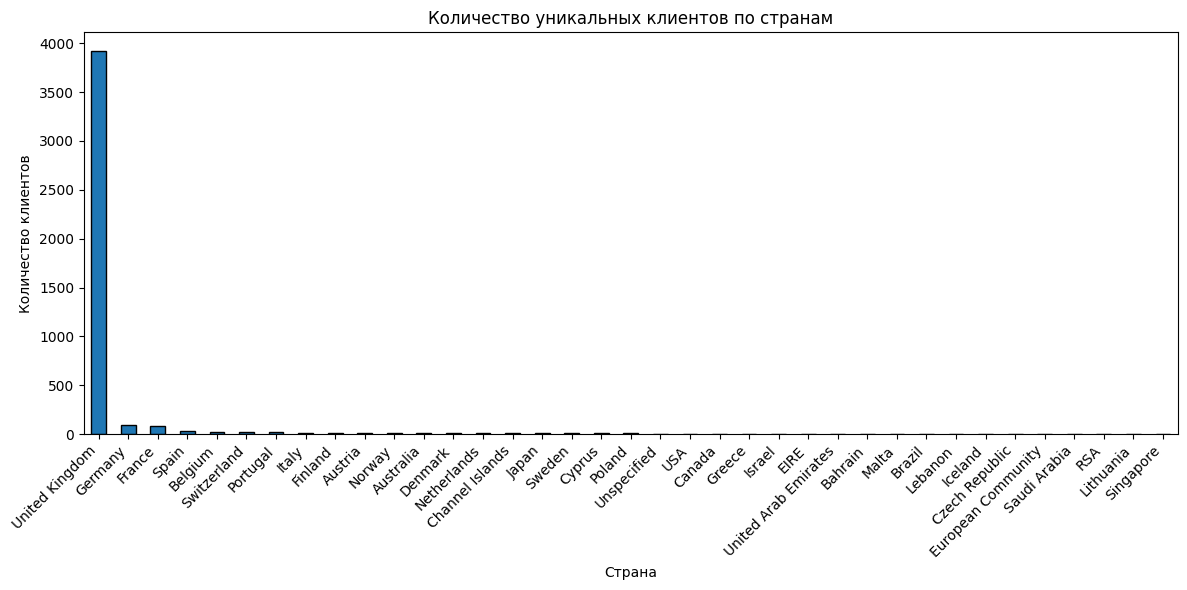

Топ стран:
Country
United Kingdom    3916
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

Наибольшее количество клиентов в: United Kingdom


In [110]:
# Подсчёт уникальных клиентов по странам
customers_by_country = data.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(12, 6))
customers_by_country.plot(kind='bar')
plt.title('Количество уникальных клиентов по странам')
plt.xlabel('Страна')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Страна с наибольшим количеством клиентов
print(f"Топ стран:\n{customers_by_country.head(10)}")
print(f"\nНаибольшее количество клиентов в: {customers_by_country.idxmax()}")

### Задание 4.2
Мы посмотрели на распределение клиентов в разрезе стран. А что насчёт заказов?

Постройте визуализацию и выделите топ-3 стран по количеству поступающих заказов.

* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


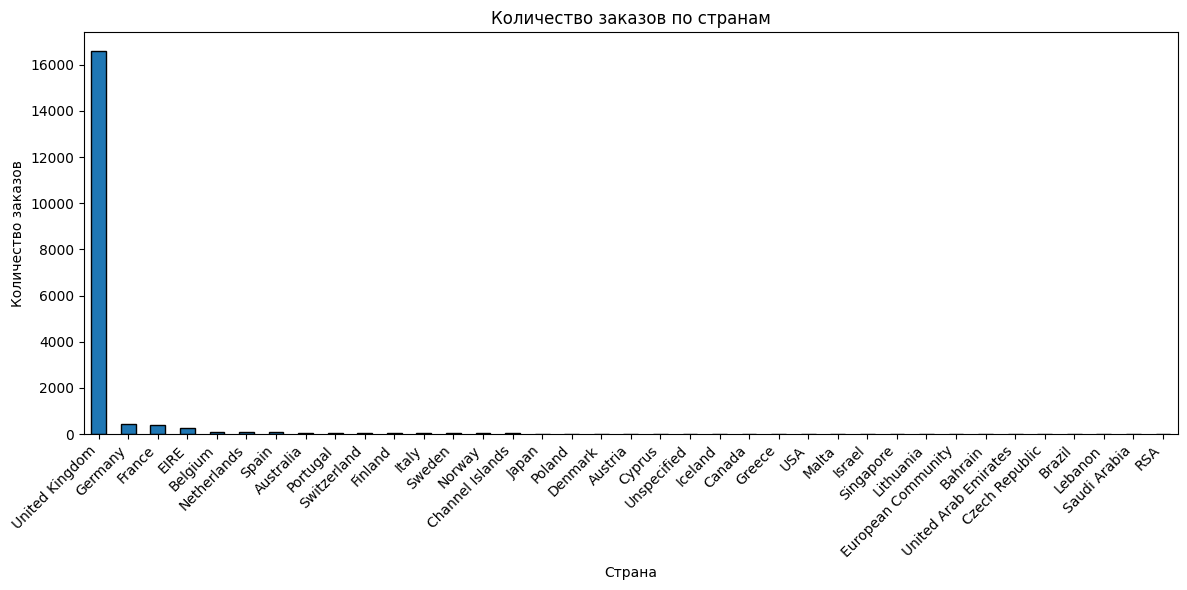

Топ стран по количеству заказов:
Country
United Kingdom    16579
Germany             443
France              379
EIRE                256
Belgium              98
Netherlands          93
Spain                88
Australia            56
Portugal             49
Switzerland          47
Name: InvoiceNo, dtype: int64

Топ-3: ['United Kingdom', 'Germany', 'France']


In [111]:
# Подсчёт количества заказов по странам
orders_by_country = data.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(12, 6))
orders_by_country.plot(kind='bar')
plt.title('Количество заказов по странам')
plt.xlabel('Страна')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Топ-3 стран
print(f"Топ стран по количеству заказов:\n{orders_by_country.head(10)}")
print(f"\nТоп-3: {orders_by_country.head(3).index.tolist()}")

### Задание 4.3
Давайте добавим в датасет общую цену заказа, назовём её TotalPrice.
Общая цена заказа рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Чему равна средняя общая стоимость заказов? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [112]:
# Создание столбца TotalPrice
data['TotalPrice'] = data['UnitPrice'] * (data['Quantity'] - data['QuantityCanceled'])

# Средняя общая стоимость заказов
avg_total_price = data['TotalPrice'].mean()
print(round(avg_total_price))

21


### Задание 4.4

Постройте визуализацию и выделите топ-3 стран, клиенты из которых приносят компании больше всего выручки:
* Великобритания (United Kingdom)
* Германия (Germany)
* Франция (France)
* Нидерланды (Netherlands)
* Ирландия (EIRE)
* Австралия (Australia)


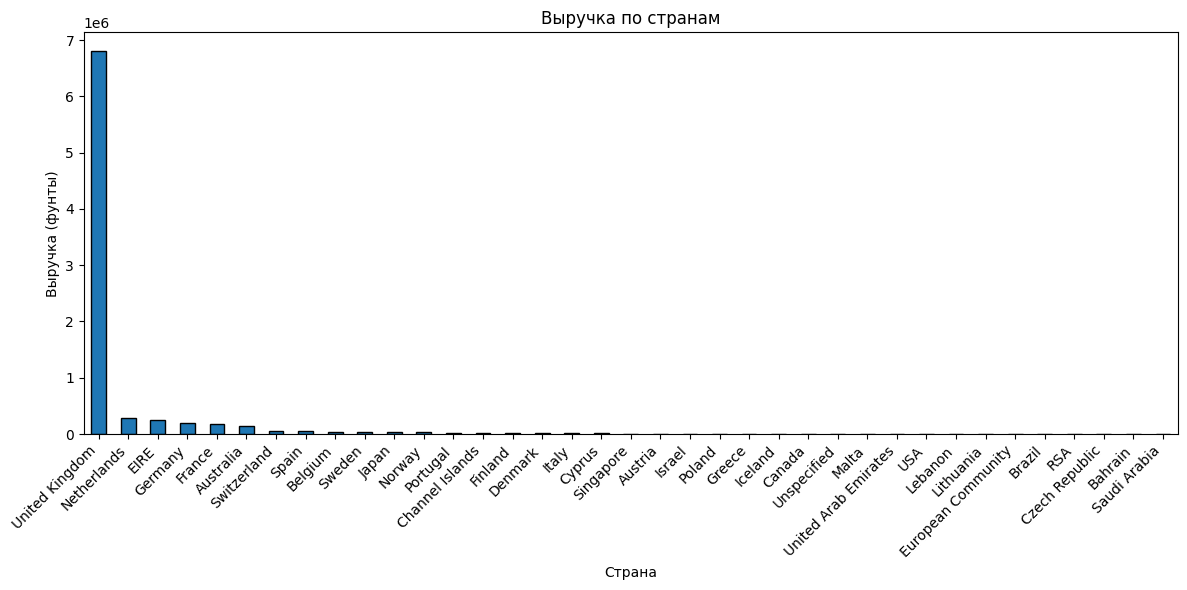

Топ стран по выручке:
Country
United Kingdom    6797691.44
Netherlands        283443.54
EIRE               247074.57
Germany            201520.71
France             181529.63
Australia          136950.25
Switzerland         51863.75
Spain               51764.90
Belgium             36673.04
Sweden              36362.91
Name: TotalPrice, dtype: float64

Топ-3: ['United Kingdom', 'Netherlands', 'EIRE']


In [113]:
# Выручка по странам
revenue_by_country = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(12, 6))
revenue_by_country.plot(kind='bar')
plt.title('Выручка по странам')
plt.xlabel('Страна')
plt.ylabel('Выручка (фунты)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Топ-3 стран
print(f"Топ стран по выручке:\n{revenue_by_country.head(10)}")
print(f"\nТоп-3: {revenue_by_country.head(3).index.tolist()}")

Теперь займёмся временными характеристиками.


### Задание 4.5
Добавьте в таблицу с транзакциями признаки месяца, дня недели и часа совершения покупки.

Постройте визуализацию, отражающую распределение суммарной выручки от заказов по месяцам. Укажите номер самого прибыльного для компании месяца. Предположите, почему так происходит.

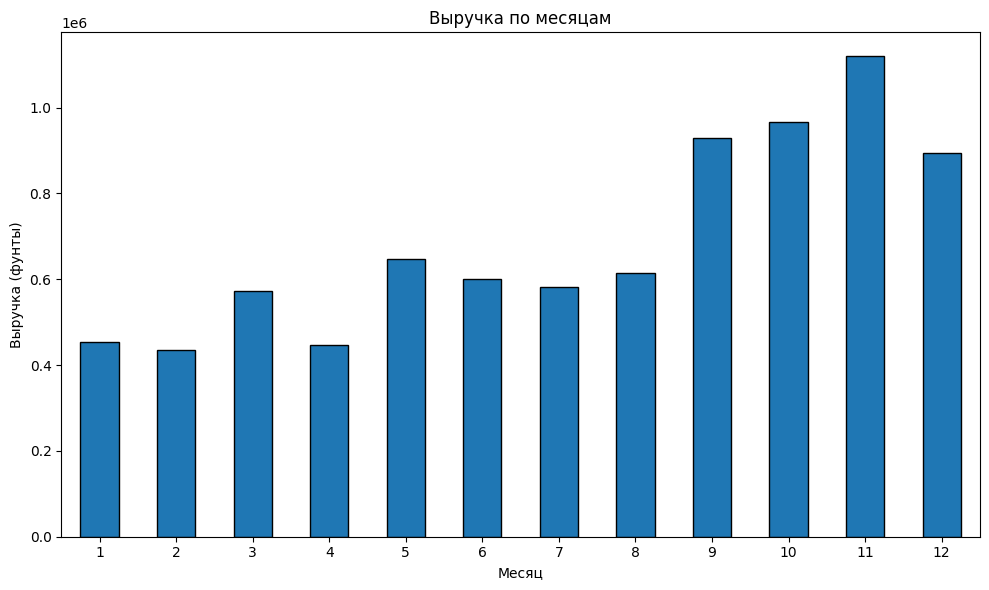

Выручка по месяцам:
Month
1      453560.68
2      436043.09
3      571941.01
4      447922.86
5      647403.81
6      601238.45
7      581019.35
8      614704.38
9      928554.44
10     967436.46
11    1119641.60
12     894126.86
Name: TotalPrice, dtype: float64

Самый прибыльный месяц: 11


In [114]:
# Добавление признаков времени
data['Month'] = data['InvoiceDate'].dt.month
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek
data['Hour'] = data['InvoiceDate'].dt.hour

# Выручка по месяцам
revenue_by_month = data.groupby('Month')['TotalPrice'].sum()

# Построение графика
plt.figure(figsize=(10, 6))
revenue_by_month.plot(kind='bar')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка (фунты)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Самый прибыльный месяц
most_profitable_month = revenue_by_month.idxmax()
print(f"Выручка по месяцам:\n{revenue_by_month}")
print(f"\nСамый прибыльный месяц: {most_profitable_month}")

### Задание 4.6
Постройте визуализацию количества заказов для каждого дня недели. Укажите день недели, в который, согласно данным, не совершено ни одного заказа:
* Понедельник
* Вторник
* Среда
* Четверг
* Пятница
* Суббота 
* Воскресенье


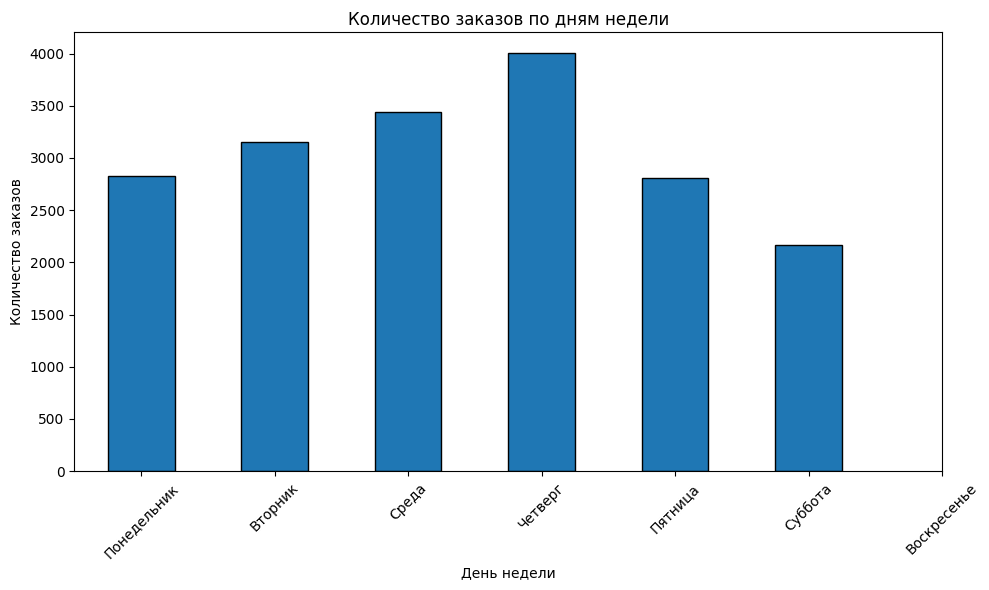

Заказы по дням недели:
DayOfWeek
0    2830
1    3156
2    3436
3    4003
4    2809
6    2168
Name: InvoiceNo, dtype: int64

Отсутствующие дни (номер): {5}
День без заказов: Суббота


In [115]:
# Количество заказов по дням недели
orders_by_day = data.groupby('DayOfWeek')['InvoiceNo'].nunique()

# Названия дней недели
day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

# Построение графика
plt.figure(figsize=(10, 6))
orders_by_day.plot(kind='bar')
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(range(7), day_names, rotation=45)
plt.tight_layout()
plt.show()

# Проверка, какие дни отсутствуют
all_days = set(range(7))
present_days = set(orders_by_day.index)
missing_days = all_days - present_days

print(f"Заказы по дням недели:\n{orders_by_day}")
print(f"\nОтсутствующие дни (номер): {missing_days}")
if missing_days:
    print(f"День без заказов: {day_names[list(missing_days)[0]]}")

### Задание 4.7
Выделите дату из признака времени совершения транзакции.
Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.

Постройте визуализацию, отражающую распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции).

Выберите верные утверждения:
* Больше всего заказов совершается в дневное время в интервале от 18 до 20 часов
* Больше всего заказов совершается в вечернее время в интервале от 10 до 15 часов
* Начиная с 21 часа вечера и до 6 утра (не включительно) заказы не поступают 
* Заказы поступают во все периоды дня


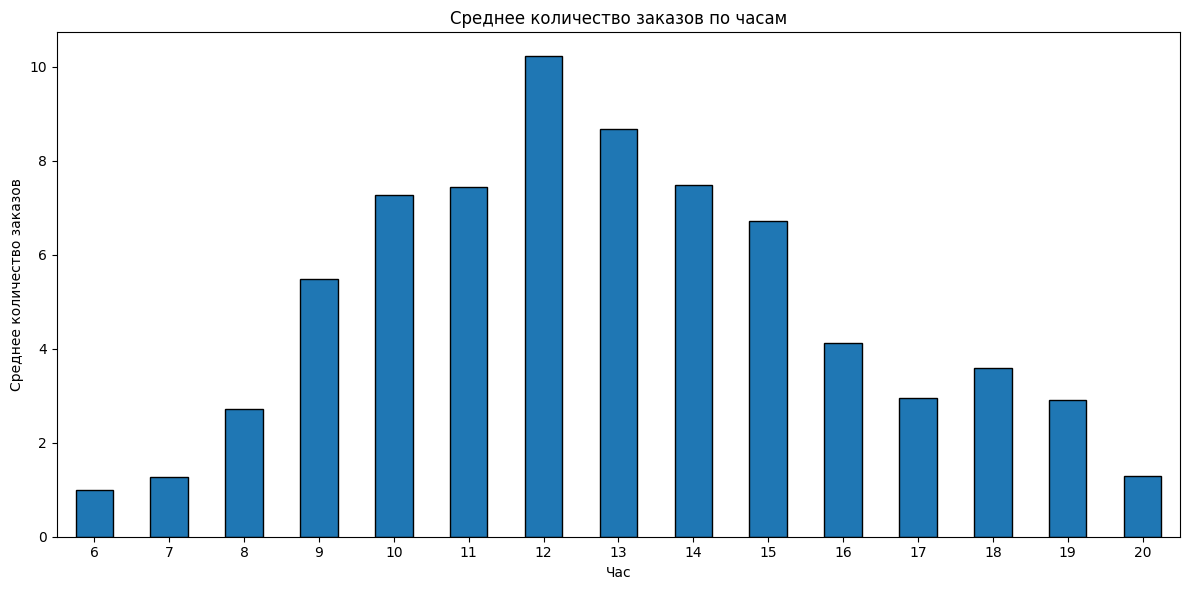

Среднее количество заказов по часам:
Hour
6      1.000000
7      1.260870
8      2.715686
9      5.488095
10     7.273927
11     7.440789
12    10.222951
13     8.685430
14     7.478405
15     6.714286
16     4.121212
17     2.945355
18     3.595745
19     2.918367
20     1.285714
Name: OrderCount, dtype: float64

Часы с нулевым количеством заказов: []


In [116]:
# Выделение даты
data['Date'] = data['InvoiceDate'].dt.date

# Группировка по дате и часу, подсчёт количества заказов
orders_by_date_hour = data.groupby(['Date', 'Hour'])['InvoiceNo'].nunique().reset_index()
orders_by_date_hour.columns = ['Date', 'Hour', 'OrderCount']

# Среднее количество заказов по часам
avg_orders_by_hour = orders_by_date_hour.groupby('Hour')['OrderCount'].mean()

# Построение графика
plt.figure(figsize=(12, 6))
avg_orders_by_hour.plot(kind='bar')
plt.title('Среднее количество заказов по часам')
plt.xlabel('Час')
plt.ylabel('Среднее количество заказов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Среднее количество заказов по часам:\n{avg_orders_by_hour}")
print(f"\nЧасы с нулевым количеством заказов: {avg_orders_by_hour[avg_orders_by_hour == 0].index.tolist()}")

## 5. RFM-сегментация клиентов: часть 1

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов.

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

### Задание 5.1

Итак, приступим к созданию нашей RFM-таблицы. 

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учетом возвратов).

Когда вы рассчитаете все характеристики, не забудьте дать столбцам результирующей таблицы соответствующие названия.

In [117]:
# Точка отсчёта для Recency
t0 = pd.to_datetime('2011-12-10 00:00:00')

# Расчёт RFM-характеристик
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': 'max',  # Последняя покупка
    'InvoiceNo': 'nunique',  # Количество уникальных заказов
    'TotalPrice': 'sum'  # Общая сумма покупок
}).reset_index()

# Переименование столбцов
rfm.columns = ['CustomerID', 'LastPurchase', 'Frequency', 'Monetary']

# Расчёт Recency (в днях)
rfm['Recency'] = (t0 - rfm['LastPurchase']).dt.days

# Удаление столбца LastPurchase (он больше не нужен)
rfm = rfm.drop('LastPurchase', axis=1)

# Перемещение Recency на первое место
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

print(rfm.head())
print(f"\nРазмер RFM-таблицы: {rfm.shape}")

  CustomerID  Recency  Frequency  Monetary
0      12346      325          1      0.00
1      12347        2          7   4310.00
2      12348       75          4   1437.24
3      12349       18          1   1457.55
4      12350      310          1    294.40

Размер RFM-таблицы: (4334, 4)


1) Сколько клиентов совершили покупку более 200 дней назад?

2) Сколько заказов в среднем делает клиент (за представленный годовой период)? Ответ округлите до целого числа.

3) Чему равна общая сумма денег, которую потратил клиент с идентификатором 12360? Ответ приведите в фунтах стерлингов и округлите до целого числа.



In [118]:
# 1) Клиенты с покупкой более 200 дней назад
customers_200_days = (rfm['Recency'] > 200).sum()
print(f"1) Клиентов с покупкой > 200 дней назад: {customers_200_days}")

# 2) Среднее количество заказов на клиента
avg_orders = round(rfm['Frequency'].mean())
print(f"2) Среднее количество заказов на клиента: {avg_orders}")

# 3) Общая сумма для клиента 12360
customer_12360 = rfm[rfm['CustomerID'] == '12360']['Monetary'].values[0]
print(f"3) Сумма для клиента 12360: {round(customer_12360)}")

1) Клиентов с покупкой > 200 дней назад: 743
2) Среднее количество заказов на клиента: 4
3) Сумма для клиента 12360: 2302


Теперь давайте взглянем на коробчатые диаграммы для каждого из признаков:

In [119]:
boxes = [px.box(rfm_table, x=column) for column in rfm_table.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency","Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
fig.write_html('plotly/boxplot_1.html')
fig.show()

NameError: name 'rfm_table' is not defined

Что интересного здесь можно увидеть? Есть клиенты с аномально большим количеством сделанных заказов (более 100 штук), а также клиенты, общая стоимость заказов которых превышает 190 тысяч фунтов стерлингов.

Чем это плохо? Выбросы могут отрицательно сказаться на результатах работы методов кластеризации, неустойчивых к ним, например алгоритма KMeans, поэтому хотелось бы от них избавиться. Однако терять много ценных данных о клиентах тоже не хочется, поэтому ограничимся верхней границей соответствующей квантили уровня 0.95. Таким образом, мы удалим данные тех клиентов, для которых значение параметра Frequency или параметра Monetary выше, чем у 95 % клиентов.


### Задание 5.2
Удалите из RFM-таблицы записи о клиентах, для которых выполняется хотя бы одно из условий:

$$frequency >frequency_{0.95}$$
$$monetary >monetary_{0.95}$$ 

где $frequency_{0.95}$ и $monetary_{0.95}$ - квантили уровня 0.95 для соответствующих признаков. 

Данные о скольких клиентах у вас остались в RFM-таблице?


In [120]:
# Расчёт 95-го процентиля для Frequency и Monetary
freq_95 = rfm['Frequency'].quantile(0.95)
monetary_95 = rfm['Monetary'].quantile(0.95)

print(f"Frequency 95-й процентиль: {freq_95}")
print(f"Monetary 95-й процентиль: {monetary_95}")

# Удаление выбросов
rfm_filtered = rfm[(rfm['Frequency'] <= freq_95) & (rfm['Monetary'] <= monetary_95)]

print(f"\nКоличество клиентов после фильтрации: {len(rfm_filtered)}")

Frequency 95-й процентиль: 13.0
Monetary 95-й процентиль: 5659.851999999997

Количество клиентов после фильтрации: 4044


После удаления выбросов у вас должны получиться следующие коробчатые диаграммы:


In [121]:
boxes = [px.box(rfm_table_cleaned, x=column) for column in rfm_table_cleaned.columns]
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        "Recency", "Frequency", "Monetary"
    )
)

for i, box in enumerate(boxes):
    fig.add_trace(boxes[i]['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
fig.write_html('plotly/boxplot_2.html')
fig.show()

NameError: name 'rfm_table_cleaned' is not defined

Мы наконец добрались до этапа кластеризации. Для начала нам необходимо оценить, как распределены наблюдения в пространстве признаков. Благо, у нас всего три параметра, по которым мы хотим кластеризовать клиентов, поэтому данные можно визуализировать в виде трёхмерной диаграммы рассеяния. 

Построим визуализацию нашего трёхмерного пространства признаков:


In [ ]:
# создадим трёхмерный объект
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)
# добавим дополнительную ось в объект картинки
fig.add_axes(ax)
ax.azim = 20
ax.elev = 30

# визуализируем данные, передав значения x, y, z, а также информацию о группировке данных по цветам
ax.scatter(
    rfm_table_cleaned['Recency'].to_list(), 
    rfm_table_cleaned['Frequency'].to_list(),
    rfm_table_cleaned['Monetary'].to_list()
)
# добавим оси
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary');


Что здесь можно увидеть? На самом деле, ничего конкретного. Да, видно, что есть клиенты с большими значениями параметров Monetary и Frequency — вероятно, это лучшие клиенты, которые покупают чаще всего и приносят больше всего денег. Однако по общей массе точек сложно сказать, сколько кластеров у нас есть — скорее даже кажется, что пространство не поддаётся кластеризации.

Давайте призовём на помощь методы снижения размерности.


### Задание 5.3
Начнём с метода главных компонент (PCA). Нам известно, что для его стабильной работы данные необходимо стандартизировать/нормализовать. 

Давайте для удобства обернём эти шаги по предобработке данных в pipeline.

Создайте pipeline, в котором будут следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* метод главных компонент с двумя компонентами.

Обучите ваш pipeline на RFM-таблице, очищенной от выбросов, и примените к ней трансформацию.

Какую долю дисперсии исходных данных объясняет первая главная компонента? Ответ округлите до двух знаков после точки-разделителя.



In [122]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Берём только числовые RFM-признаки
X = rfm_filtered[['Recency', 'Frequency', 'Monetary']]

# Создаём pipeline
rfm_pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Обучение и трансформация
rfm_pca_pipe.fit(X)
X_pca = rfm_pca_pipe.transform(X)

# Доля объяснённой дисперсии
explained_variance = rfm_pca_pipe.named_steps['pca'].explained_variance_ratio_
print(explained_variance)
print(f"Первая компонента объясняет: {explained_variance[0]:.2f}")

[0.67747053 0.24012744]
Первая компонента объясняет: 0.68


Визуализировав пространство главных компонент после декомпозиции мы получим следующую картину:

In [123]:
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2');

NameError: name 'rfm_table_processed' is not defined

Попробуем разделить это пространство главных компонент на сегменты. 

### Задание 5.4
Попробуем воспользоваться методом k-means. 

Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


In [124]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Используем данные после PCA
X_pca_data = rfm_pca_pipe.transform(X)

# Перебор количества кластеров от 2 до 10
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca_data)
    score = silhouette_score(X_pca_data, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

# Оптимальное количество кластеров
best_k = silhouette_scores.index(max(silhouette_scores)) + 2
max_silhouette = max(silhouette_scores)

print(f"\nОптимальное количество кластеров: {best_k}")
print(f"Максимальный коэффициент силуэта: {max_silhouette:.2f}")

k=2: silhouette=0.5002
k=3: silhouette=0.5241
k=4: silhouette=0.4976
k=5: silhouette=0.4491
k=6: silhouette=0.4480
k=7: silhouette=0.4455
k=8: silhouette=0.4244
k=9: silhouette=0.4223
k=10: silhouette=0.4130

Оптимальное количество кластеров: 3
Максимальный коэффициент силуэта: 0.52


### Задание 5.5
Теперь возьмём EM-алгоритм.

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture) с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно.
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.


In [125]:
from sklearn.mixture import GaussianMixture

# Перебор количества кластеров от 2 до 10 для EM-алгоритма
silhouette_scores_em = []
for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_pca_data)
    score = silhouette_score(X_pca_data, labels)
    silhouette_scores_em.append(score)
    print(f"k={k}: silhouette={score:.4f}")

# Оптимальное количество кластеров
best_k_em = silhouette_scores_em.index(max(silhouette_scores_em)) + 2
max_silhouette_em = max(silhouette_scores_em)

print(f"\nОптимальное количество кластеров: {best_k_em}")
print(f"Максимальный коэффициент силуэта: {max_silhouette_em:.2f}")

k=2: silhouette=0.3425
k=3: silhouette=0.4358
k=4: silhouette=0.3501
k=5: silhouette=0.2797
k=6: silhouette=0.2726
k=7: silhouette=0.2366
k=8: silhouette=0.1952
k=9: silhouette=0.1624
k=10: silhouette=0.1452

Оптимальное количество кластеров: 3
Максимальный коэффициент силуэта: 0.44


### Задание 5.6
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [146]:
# K-Means с k=2
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k2 = kmeans_k2.fit_predict(X_pca_test)

cluster_counts_k2 = pd.Series(labels_k2).value_counts().sort_values(ascending=False)
print(f"k=2: {cluster_counts_k2}")
print(f"Самый большой кластер: {cluster_counts_k2.iloc[0]}")

k=2: 1    3046
0     998
Name: count, dtype: int64
Самый большой кластер: 3046


Визуализируем результаты кластеризации:

In [143]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=rfm_table_processed, 
    x='axis-1', 
    y='axis-2', 
    hue=labels,
);

NameError: name 'rfm_table_processed' is not defined

<Figure size 1200x500 with 0 Axes>

Итак, у нас есть три сегмента клиентов. Давайте попробуем составить профиль для этих сегментов.

### Задание 5.7

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице, очищенной от выбросов.  Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чему равно максимальное среднее значение признака Frequency в полученной таблице? Ответ округлите до целого числа.

In [147]:
# Добавляем метки кластеров в RFM-таблицу
rfm_with_clusters = rfm_filtered.copy()
rfm_with_clusters['Cluster'] = labels

# Группируем по кластерам и считаем среднее
cluster_profile = rfm_with_clusters.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("Профиль кластеров (средние значения):")
print(cluster_profile)

# Находим максимальное среднее значение Frequency
max_freq_mean = cluster_profile['Frequency'].max()
print(f"\nМаксимальное среднее значение Frequency: {max_freq_mean}")
print(f"Округлённое до целого: {round(max_freq_mean)}")

Профиль кластеров (средние значения):
            Recency  Frequency     Monetary
Cluster                                    
0         51.127481   2.329069   660.168677
1         31.943299   7.068299  2657.746997
2        253.283716   1.405594   386.598472

Максимальное среднее значение Frequency: 7.068298969072165
Округлённое до целого: 7


### Полярная диаграмма
Сейчас мы познакомимся с одним из способов визуализации профиля кластеров — Radar Chart (полярная, или лепестковая, диаграмма). Это графическое представление значений нескольких эквивалентных категорий в форме «паутины».
Radar Chart очень часто используется в контексте определения профиля кластеров. На концах «паутины» откладываются оси, которые соответствуют признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 
Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На данной диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие к данному кластеру, в большей степени увлекаются музыкой (Music), а в меньшей степени — программированием (Programm).

В модуле graph_objects библиотеки plotly есть встроенная функция Scatterpolar, которая позволяет построить полярную диаграмму. На основе этой функции мы реализовали собственную функцию plot_cluster_profile(), которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У этой функции два параметра: grouped_data — сгруппированные по кластерам характеристики объектов (клиентов), n_clusters — количество кластеров. 

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в реализацию функции plot_cluster_profile().

In [148]:
def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаем список признаков
    features = grouped_data.columns
    # Создаем пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаем полярную диаграмму и добавляем ее на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название - номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()
    

Теперь у нас есть удобный инструмент для анализа профиля кластеров. Давайте воспользуемся им.


### Задание 5.8

Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера. 

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

Описание кластера:
* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «промежуточным» клиентам, которые являются активными, но покупают не так часто и много, как лояльные клиенты. В то же время эти клиенты не являются «потерянными».
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена очень давно.


In [150]:
from sklearn import preprocessing
import plotly.graph_objects as go

def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаем список признаков
    features = grouped_data.columns
    # Создаем пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаем полярную диаграмму и добавляем ее на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название - номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()

# Визуализируем профили кластеров
plot_cluster_profile(cluster_profile, n_clusters=3)
print(cluster_profile)

            Recency  Frequency     Monetary
Cluster                                    
0         51.127481   2.329069   660.168677
1         31.943299   7.068299  2657.746997
2        253.283716   1.405594   386.598472


### 4. RFM-сегментация клиентов: часть 2

Итак, с помощью RFM-анализа нам удалось выделить три сегмента клиентов. Однако в маркетинге принято оперировать большим их количеством: обычно маркетологи стараются создать стратегию хотя бы для пяти-семи клиентских сегментов в градации от «лояльных» до «потерянных» с промежуточными категориями.

Поэтому, получив обратную связь от маркетологов, мы вновь принимаемся за работу, пытаясь модифицировать полученное решение.

Ранее мы производили кластеризацию в пространстве главных компонент. Вспомним, что PCA является линейным методом отображения исходного пространства признаков в его сжатую версию.

А что если использовать нелинейную трансформацию? Например, алгоритм снижения размерности t-SNE. Давайте попробуем и посмотрим, что получится.

### Задание 6.1
Воспользуемся алгоритмом t-SNE и трансформируем RFM-таблицу, очищенную от выбросов, в двухмерное представление. Также заранее позаботимся о масштабировании признаков.

Давайте для удобства обернём шаги по предобработке данных в pipeline.

Создайте pipeline, который будет содержать следующие шаги:
* стандартизация с помощью StandardScaler с параметрами по умолчанию; 
* алгоритм t-SNE с двумя компонентами, параметрами perplexity=50 и random_state=100.

Обучите ваш pipeline на RFM-таблице (очищенной от выбросов), полученной ранее, и примените к ней трансформацию.

Чему равно значение дивергенции Кульбака — Лейблера для обученного алгоритма t-SNE? Ответ округлите до двух знаков после точки-разделителя.

**Примечание:**
Напомним, что дивергенция Кульбака-Лейблера - это функция потерь, которая минимизируется при обучения алгоритма t-SNE. Она показывает меру расстояния между двумя распределениями. 

Оптимальное значение данной характеристики, найденное в процессе обучения алгоритма t-SNE, хранится в атрибуте kl_divergence_ объекта класса TSNE из библиотеки sklearn. Конечно же, предварительно модель необходимо обучить, чтобы получить это значение.



In [151]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Создаём pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, perplexity=50, random_state=100))
])

# Обучаем pipeline и трансформируем данные
X_tsne = pipeline.fit_transform(rfm_filtered[['Recency', 'Frequency', 'Monetary']])

# Получаем значение дивергенции Кульбака-Лейблера
kl_div = pipeline.named_steps['tsne'].kl_divergence_
print(f"Дивергенция Кульбака-Лейблера: {kl_div}")
print(f"Округлённое до двух знаков: {round(kl_div, 2)}")

Дивергенция Кульбака-Лейблера: 0.5407859086990356
Округлённое до двух знаков: 0.54


Визуализировав пространство после декомпозиции с помощью t-SNE, мы получим следующую картину:


In [ ]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2');

Как и ожидалось от t-SNE, алгоритм сгруппировал наиболее похожие объекты в подобие кластеров, причём эти кластеры легко определить.

Теперь давайте воспользуемся алгоритмами кластеризации, чтобы сформировать новые сегменты клиентов.


### Задание 6.2
Попробуем воспользоваться методом k-means. 
Подберите оптимальное количество кластеров для метода k-means с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 
В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



In [152]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Перебираем количество кластеров от 3 до 8
silhouette_scores = {}

for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_tsne)  # используем t-SNE данные
    score = silhouette_score(X_tsne, labels)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette_score={score:.4f}")

# Находим оптимальное количество кластеров
best_k = max(silhouette_scores, key=silhouette_scores.get)
max_score = silhouette_scores[best_k]

print(f"\nОптимальное количество кластеров: {best_k}")
print(f"Максимальное значение коэффициента силуэта: {max_score:.4f}")
print(f"Округлённое до двух знаков: {round(max_score, 2)}")

k=3: silhouette_score=0.4286
k=4: silhouette_score=0.4808
k=5: silhouette_score=0.4793
k=6: silhouette_score=0.4818
k=7: silhouette_score=0.4370
k=8: silhouette_score=0.4987

Оптимальное количество кластеров: 8
Максимальное значение коэффициента силуэта: 0.4987
Округлённое до двух знаков: 0.5


### Задание 6.3
Попробуем воспользоваться EM-алгоритом. 

Подберите оптимальное количество кластеров для EM-алгоритма (GaussianMixture)  с помощью коэффициента силуэта, перебирая возможные значения от 3 до 8 включительно. 

В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.

In [156]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Перебираем количество кластеров от 3 до 8 на t-SNE данных
silhouette_scores_gmm_tsne = {}

for k in range(3, 9):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_tsne)
    score = silhouette_score(X_tsne, labels)
    silhouette_scores_gmm_tsne[k] = score
    print(f"k={k}: silhouette_score={score:.4f}")

# Находим оптимальное количество кластеров
best_k_gmm_tsne = max(silhouette_scores_gmm_tsne, key=silhouette_scores_gmm_tsne.get)
max_score_gmm_tsne = silhouette_scores_gmm_tsne[best_k_gmm_tsne]

print(f"\nОптимальное количество кластеров: {best_k_gmm_tsne}")
print(f"Максимальное значение коэффициента силуэта: {max_score_gmm_tsne:.4f}")
print(f"Округлённое до двух знаков: {round(max_score_gmm_tsne, 2)}")

k=3: silhouette_score=0.4080
k=4: silhouette_score=0.4709
k=5: silhouette_score=0.3778
k=6: silhouette_score=0.3836
k=7: silhouette_score=0.3464
k=8: silhouette_score=0.3863

Оптимальное количество кластеров: 4
Максимальное значение коэффициента силуэта: 0.4709
Округлённое до двух знаков: 0.47


### Задание 6.4
Наконец, попробуем воспользоваться алгоритмом алгомеративной кластеризации (AgglomerativeClustering).

Подберите оптимальное количество кластеров для алгоритма агломеративной кластеризации с помощью коэффициента силуэта, перебирая возможные значения от 2 до 8 включительно. 

Все параметры, за исключением числа кластеров, оставьте по умолчанию.


1) Судя по полученным результатам, какое количество кластеров лучше всего взять?

2) Чему равно максимальное значение коэффициента силуэта? Ответ округлите до двух знаков после точки-разделителя.



In [157]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores_agg = {}

# Перебираем количество кластеров от 2 до 8
for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k)  # все параметры по умолчанию
    labels = agg.fit_predict(X_tsne)            # используем t-SNE данные
    score = silhouette_score(X_tsne, labels)
    silhouette_scores_agg[k] = score
    print(f"k={k}: silhouette_score={score:.4f}")

best_k_agg = max(silhouette_scores_agg, key=silhouette_scores_agg.get)
max_score_agg = silhouette_scores_agg[best_k_agg]

print(f"\nОптимальное количество кластеров: {best_k_agg}")
print(f"Максимальное значение коэффициента силуэта: {max_score_agg:.4f}")
print(f"Округлённое до двух знаков: {round(max_score_agg, 2)}")

k=2: silhouette_score=0.3848
k=3: silhouette_score=0.4289
k=4: silhouette_score=0.4489
k=5: silhouette_score=0.4619
k=6: silhouette_score=0.4581
k=7: silhouette_score=0.4709
k=8: silhouette_score=0.4900

Оптимальное количество кластеров: 8
Максимальное значение коэффициента силуэта: 0.4900
Округлённое до двух знаков: 0.49


### Задание 6.5
Давайте посмотрим на распределение кластеров.

1) Сначала нужно определить лучшую модель. Для какой модели с оптимальным количеством кластеров коэффициент силуэта наибольший?
* K-Means
* GaussianMixture
* AgglomerativeClustering


2) Обучите лучшую модель с подобранным ранее количеством кластеров на декомпозированных данных. 
Сколько клиентов попало в самый большой кластер?



In [158]:
# Выводим лучшие silhouette scores для всех трёх моделей
print("K-Means (на t-SNE):")
for k, score in silhouette_scores.items():
    print(f"  k={k}: {score:.4f}")
print(f"  Лучший: k={best_k}, score={silhouette_scores[best_k]:.4f}")

print("\nGaussianMixture (на t-SNE, n_init=10):")
for k, score in silhouette_scores_gmm_tsne.items():
    print(f"  k={k}: {score:.4f}")
print(f"  Лучший: k={best_k_gmm_tsne}, score={silhouette_scores_gmm_tsne[best_k_gmm_tsne]:.4f}")

print("\nAgglomerativeClustering (на t-SNE):")
for k, score in silhouette_scores_agg.items():
    print(f"  k={k}: {score:.4f}")
print(f"  Лучший: k={best_k_agg}, score={silhouette_scores_agg[best_k_agg]:.4f}")

# Сравниваем лучшие scores
best_models = {
    'K-Means': silhouette_scores[best_k],
    'GaussianMixture': silhouette_scores_gmm_tsne[best_k_gmm_tsne],
    'AgglomerativeClustering': silhouette_scores_agg[best_k_agg]
}

best_model_name = max(best_models, key=best_models.get)
print(f"\nЛучшая модель: {best_model_name} (score={best_models[best_model_name]:.4f})")

K-Means (на t-SNE):
  k=3: 0.4286
  k=4: 0.4808
  k=5: 0.4793
  k=6: 0.4818
  k=7: 0.4370
  k=8: 0.4987
  Лучший: k=8, score=0.4987

GaussianMixture (на t-SNE, n_init=10):
  k=3: 0.4080
  k=4: 0.4709
  k=5: 0.3778
  k=6: 0.3836
  k=7: 0.3464
  k=8: 0.3863
  Лучший: k=4, score=0.4709

AgglomerativeClustering (на t-SNE):
  k=2: 0.3848
  k=3: 0.4289
  k=4: 0.4489
  k=5: 0.4619
  k=6: 0.4581
  k=7: 0.4709
  k=8: 0.4900
  Лучший: k=8, score=0.4900

Лучшая модель: K-Means (score=0.4987)


In [164]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

# Перебираем k от 3 до 7 для всех моделей на t-SNE-данных
silhouette_kmeans_tsne_3_7 = {}
silhouette_gmm_tsne_3_7 = {}
silhouette_agg_tsne_3_7 = {}

for k in range(3, 8):  # 3..7 включительно
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_km = kmeans.fit_predict(X_tsne)
    silhouette_kmeans_tsne_3_7[k] = silhouette_score(X_tsne, labels_km)
    
    # GaussianMixture
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels_gmm = gmm.fit_predict(X_tsne)
    silhouette_gmm_tsne_3_7[k] = silhouette_score(X_tsne, labels_gmm)
    
    # AgglomerativeClustering
    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg = agg.fit_predict(X_tsne)
    silhouette_agg_tsne_3_7[k] = silhouette_score(X_tsne, labels_agg)

# Находим лучшие для каждой модели
best_k_km_tsne_3_7 = max(silhouette_kmeans_tsne_3_7, key=silhouette_kmeans_tsne_3_7.get)
best_k_gmm_tsne_3_7 = max(silhouette_gmm_tsne_3_7, key=silhouette_gmm_tsne_3_7.get)
best_k_agg_tsne_3_7 = max(silhouette_agg_tsne_3_7, key=silhouette_agg_tsne_3_7.get)

print("K-Means на t-SNE (k=3..7):")
for k, score in silhouette_kmeans_tsne_3_7.items():
    print(f"  k={k}: {score:.4f}")
print(f"  Лучший: k={best_k_km_tsne_3_7}, score={silhouette_kmeans_tsne_3_7[best_k_km_tsne_3_7]:.4f}")

print("\nGaussianMixture на t-SNE (k=3..7):")
for k, score in silhouette_gmm_tsne_3_7.items():
    print(f"  k={k}: {score:.4f}")
print(f"  Лучший: k={best_k_gmm_tsne_3_7}, score={silhouette_gmm_tsne_3_7[best_k_gmm_tsne_3_7]:.4f}")

print("\nAgglomerativeClustering на t-SNE (k=3..7):")
for k, score in silhouette_agg_tsne_3_7.items():
    print(f"  k={k}: {score:.4f}")
print(f"  Лучший: k={best_k_agg_tsne_3_7}, score={silhouette_agg_tsne_3_7[best_k_agg_tsne_3_7]:.4f}")

# Сравниваем лучшие
best_models_tsne_3_7 = {
    'K-Means': silhouette_kmeans_tsne_3_7[best_k_km_tsne_3_7],
    'GaussianMixture': silhouette_gmm_tsne_3_7[best_k_gmm_tsne_3_7],
    'AgglomerativeClustering': silhouette_agg_tsne_3_7[best_k_agg_tsne_3_7]
}

best_model_tsne_3_7 = max(best_models_tsne_3_7, key=best_models_tsne_3_7.get)
print(f"\nЛучшая модель на t-SNE (k=3..7): {best_model_tsne_3_7} (score={best_models_tsne_3_7[best_model_tsne_3_7]:.4f})")

# Обучаем лучшую модель
if best_model_tsne_3_7 == 'K-Means':
    model_tsne_3_7 = KMeans(n_clusters=best_k_km_tsne_3_7, random_state=42)
elif best_model_tsne_3_7 == 'GaussianMixture':
    model_tsne_3_7 = GaussianMixture(n_components=best_k_gmm_tsne_3_7, random_state=42, n_init=10)
else:
    model_tsne_3_7 = AgglomerativeClustering(n_clusters=best_k_agg_tsne_3_7)

labels_best_tsne_3_7 = model_tsne_3_7.fit_predict(X_tsne)
cluster_counts_tsne_3_7 = pd.Series(labels_best_tsne_3_7).value_counts().sort_values(ascending=False)
print(f"\nРаспределение по кластерам:\n{cluster_counts_tsne_3_7}")
print(f"Самый большой кластер: {cluster_counts_tsne_3_7.iloc[0]}")

K-Means на t-SNE (k=3..7):
  k=3: 0.4286
  k=4: 0.4808
  k=5: 0.4793
  k=6: 0.4818
  k=7: 0.4370
  Лучший: k=6, score=0.4818

GaussianMixture на t-SNE (k=3..7):
  k=3: 0.4080
  k=4: 0.4709
  k=5: 0.3778
  k=6: 0.3836
  k=7: 0.3464
  Лучший: k=4, score=0.4709

AgglomerativeClustering на t-SNE (k=3..7):
  k=3: 0.4289
  k=4: 0.4489
  k=5: 0.4619
  k=6: 0.4581
  k=7: 0.4709
  Лучший: k=7, score=0.4709

Лучшая модель на t-SNE (k=3..7): K-Means (score=0.4818)

Распределение по кластерам:
0    914
3    814
2    682
5    680
4    537
1    417
Name: count, dtype: int64
Самый большой кластер: 914


Визуализируем результаты кластеризации:

In [ ]:
fig = plt.figure(figsize=(12, 5))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2', hue=model.labels_.astype('str'));


Итак, у нас есть 7 сегментов клиентов. Давайте попробуем составить профиль для этих сегментов. 


### Задание 6.6

Для составления профиля кластеров нам необходимо вернуться от декомпозированных данных к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков. Для наглядности округлите все значения в столбцах до целого числа.

Чему равно максимальное среднее значение признака Recency в полученной таблице? Ответ округлите до целого числа.

In [171]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

# Обучаем AgglomerativeClustering с k=7 на PCA данных
agg_pca_7 = AgglomerativeClustering(n_clusters=7)
labels_agg_pca_7 = agg_pca_7.fit_predict(X_pca)

# Добавляем метки кластеров в RFM-таблицу
rfm_with_clusters_agg_pca_7 = rfm_filtered.copy()
rfm_with_clusters_agg_pca_7['Cluster'] = labels_agg_pca_7

# Группируем по кластерам и считаем среднее
cluster_profile_agg_pca_7 = rfm_with_clusters_agg_pca_7.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(0)
print("Профиль кластеров (AgglomerativeClustering на PCA, k=7):")
print(cluster_profile_agg_pca_7)

# Находим максимальное среднее значение Recency
max_recency_agg_pca_7 = cluster_profile_agg_pca_7['Recency'].max()
print(f"\nМаксимальное среднее значение Recency: {max_recency_agg_pca_7}")

Профиль кластеров (AgglomerativeClustering на PCA, k=7):
         Recency  Frequency  Monetary
Cluster                              
0          191.0        2.0     443.0
1           42.0        2.0     421.0
2           35.0        6.0    2331.0
3           26.0        4.0    1172.0
4           17.0       10.0    3789.0
5          314.0        1.0     251.0
6          113.0        3.0    1197.0

Максимальное среднее значение Recency: 314.0


### Задание 6.7
Визуализируйте профили кластеров в виде полярной диаграммы на основе средних RFM-характеристик, вычисленных для каждого кластера.

Проанализируйте кластеры и на основе анализа сопоставьте номер кластера и его описание.

* Кластер соответствует «лояльным» клиентам, которые приносят наибольший доход, совершают покупки чаще всего, а давность их последней покупки наименьшая.
* Кластер соответствует «перспективным» клиентам, которые являются активными покупателями, но покупают не так часто и не так много, как лояльные клиенты.
* Кластер соответствует «подвисшим» клиентам, которые относительно недавно сделали несколько заказов на небольшие суммы. Потенциально эти клиенты могут быть переведены в кластер «перспективных».
* Кластер соответствует клиентам «в зоне риска», которые несколько раз покупали товары на небольшие суммы, однако их последняя покупка была совершена более пяти месяцев назад.
* Кластер соответствует клиентам-«новичкам», которые относительно недавно сделали один заказ на небольшую сумму. 
* Кластер соответствует «спящим» или «почти потерянным» клиентам, которые сделали один заказ на маленькую сумму более семи месяцев назад и больше не возвращались.
* Кластер соответствует «потерянным» клиентам, которые купили меньше всего товара, и их последняя покупка была совершена около года назад.



In [173]:
from sklearn.cluster import KMeans
import pandas as pd

# Обучаем K-Means с k=7 на t-SNE данных
kmeans_7 = KMeans(n_clusters=7, random_state=42)
labels_7 = kmeans_7.fit_predict(X_tsne)

# Добавляем метки кластеров в RFM-таблицу
rfm_with_clusters_7 = rfm_filtered.copy()
rfm_with_clusters_7['Cluster'] = labels_7

# Группируем по кластерам и считаем среднее
cluster_profile_7 = rfm_with_clusters_7.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("Профиль кластеров (7 кластеров):")
print(cluster_profile_7)
print(f"\nКоличество кластеров: {len(cluster_profile_7)}")

# Теперь визуализируем
plot_cluster_profile(cluster_profile_7, n_clusters=7)

Профиль кластеров (7 кластеров):
            Recency  Frequency     Monetary
Cluster                                    
0         91.570690   7.120690  2331.087655
1        234.460803   2.099426   561.180325
2         43.428058   3.287770   880.654281
3         50.868272   1.000000   318.421572
4         46.480342   1.967521   628.773333
5        215.135729   1.000000   251.461357
6         39.568297   4.650927  1841.833103

Количество кластеров: 7


## 7. RFM-кластеризация клиентов: часть 3

Мы построили модель кластеризации для части клиентов.Но как сделать предсказание сегмента для клиентов, которые не попали в обучающую выборку?

Вы, вероятно, скажете: «Воспользоваться методом predict()!»

Верно, однако всё не так просто.

Вспомним, что мы обучали наши алгоритмы кластеризации на сжатом с помощью t-SNE пространстве признаков. То есть, чтобы сделать предсказание для новых объектов, не попавших в выборку, нам необходимо будет совершить трансформацию признаков этих объектов в новое сжатое пространство. 

Однако проблема t-SNE заключается в том, что алгоритм непараметрический. Это значит, что он, в отличие от таких алгоритмов, как PCA и SVD, не создаёт явной функции отображения. Проще говоря, алгоритм трансформирует пространство признаков для обучающей выборки, но не запоминает, каким образом это делает. Это значит, что, передав в алгоритм новые объекты для сжатия пространства, мы получим абсолютно новое представление пространства, не имеющее отношения к тому, что мы построили для обучающей выборки. То есть произойдёт искажение, что может привести к неверным результатам кластеризации.

Именно поэтому у класса TSNE из библиотеки sklearn нет такого метода, как transform(), у него есть только метод fit_transform() — заново обучить алгоритм t-SNE и произвести трансформацию.

Как же тогда производить кластеризацию для новых объектов, если мы не можем сжимать размерность для новых данных?

Давайте сведём задачу кластеризации к задаче классификации. Действительно, у нас теперь есть истинные метки кластеров, а есть клиенты, которые описываются RFM-характеристиками. Давайте обучим модель, которая на основе RFM-характеристик будет предсказывать клиентский сегмент. 

### Задание 7.1

Разделите исходные данные на тренировочную и тестовую выборки в соотношении 80/20. В качестве параметра random_state возьмите число 42.

Сколько клиентов попали в тестовую выборку?

In [174]:
from sklearn.model_selection import train_test_split

# X — признаки (RFM), y — метки кластеров
X = rfm_filtered[['Recency', 'Frequency', 'Monetary']]
y = labels_7  # или тот массив меток, который ты использовал в 6.5-6.7

# Разделяем на train и test в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Размер тестовой выборки
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"Размер тренировочной выборки: {len(X_train)}")

Размер тестовой выборки: 809
Размер тренировочной выборки: 3235


Дальше нам осталось только построить несколько моделей и выбрать из них лучшую. 
Мы знаем, что алгоритм t-SNE является нелинейным методом понижения размерности. Можно смело предположить, что линейные модели, такие как логистическая регрессия, в данной задаче нам мало чем помогут (можете убедиться в этом самостоятельно, обучив модель логистической регрессии на тренировочной выборке и оценив качество на тестовой).

Поэтому давайте сразу возьмём тяжелую артиллерию — ансамблевые алгоритмы. 


### Задание 7.2
Начнём со случайного леса. С помощью GridSearchCV организуйте перебор параметров случайного леса (RandomForestClassifier) на следующей сетке параметров:

```
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}
```
В качестве параметра random_state для модели случайного леса используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5.

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в случайном лесу?

2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [181]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Сетка параметров
param_grid_gb = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}

# Создаём модель
rf = RandomForestClassifier(random_state=42)

# Создаём GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1  # использовать все ядра
)

# Обучаем GridSearchCV на тренировочной выборке
grid_search_rf.fit(X_train, y_train)

# Оптимальная максимальная глубина
best_max_depth = grid_search_rf.best_params_['max_depth']
print(f"Оптимальная максимальная глубина: {best_max_depth}")

# Лучшая модель
best_rf = grid_search_rf.best_estimator_

# Предсказание на тестовой выборке
y_pred_rf = best_rf.predict(X_test)

# Accuracy на тестовой выборке
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy на тестовой выборке: {accuracy_rf:.4f}")
print(f"Округлённое до трёх знаков: {round(accuracy_rf, 3)}")

Оптимальная максимальная глубина: 13
Accuracy на тестовой выборке: 0.9852
Округлённое до трёх знаков: 0.985


Итак, значение метрики accuracy очень высокое, но не идеальное. Давайте попробуем его улучшить, воспользовавшись бустингом.

### Задание 7.3
С помощью GridSearchCV организуйте перебор параметров градиентного бустинга (GradientBoostingClassifier) на следующей сетке параметров:
```
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}
```

В качестве параметра random_state для модели градиентного бустинга используйте число 42.
В качестве метрики используйте accuracy. Количество фолдов для кросс-валидации — 5. 

1) Обучите GridSearchCV на тренировочной выборке. Чему равна оптимальная максимальная глубина деревьев в градиентном бустинге?
Ответ: 6
2) С помощью лучшей модели сделайте предсказание для тестовой выборки и рассчитайте метрику accuracy. Ответ округлите до трёх знаков после точки-разделителя.



In [185]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Сетка параметров
param_grid_gb = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}

# Создаём модель
gb = GradientBoostingClassifier(random_state=42)

# Создаём GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Обучаем GridSearchCV на тренировочной выборке
grid_search_gb.fit(X_train, y_train)

# Оптимальная максимальная глубина
best_max_depth_gb = grid_search_gb.best_params_['max_depth']
print(f"Оптимальная максимальная глубина: {best_max_depth_gb}")

# Лучшая модель
best_gb = grid_search_gb.best_estimator_

# Предсказание на тестовой выборке
y_pred_gb = best_gb.predict(X_test)

# Accuracy на тестовой выборке
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy на тестовой выборке: {accuracy_gb:.6f}")
print(f"Округлённое до трёх знаков: {round(accuracy_gb, 3)}")

# Также посчитаем accuracy на тренировочной выборке
y_pred_gb_train = best_gb.predict(X_train)
accuracy_gb_train = accuracy_score(y_train, y_pred_gb_train)
print(f"\nAccuracy на тренировочной выборке: {accuracy_gb_train:.6f}")

# И на всей выборке
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])
y_pred_gb_full = best_gb.predict(X_full)
accuracy_gb_full = accuracy_score(y_full, y_pred_gb_full)
print(f"Accuracy на всей выборке: {accuracy_gb_full:.6f}")
print(f"Округлённое до трёх знаков: {round(accuracy_gb_full, 3)}")

Оптимальная максимальная глубина: 6
Accuracy на тестовой выборке: 0.985167
Округлённое до трёх знаков: 0.985

Accuracy на тренировочной выборке: 1.000000


TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

Отлично, мы справились с проблемой непараметричности t-SNE и смогли перейти от решения задачи кластеризации к задаче классификации. Теперь у нас есть модель, которая на основе RFM-характерик клиента автоматически определяет его сегмент.